In [1]:
import math
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wandb
from wandb.apis.public.runs import Run

In [2]:
api = wandb.Api()

In [3]:
runs = api.runs(
    "graphcore/llama-mobile",
    filters={"config.name": "sweep-05-02-26", "state": "finished"},
)

In [4]:
# Return (metric, relaxed_metric)
def get_metrics(task: str) -> tuple[str]:
    from eval.vqa import TASKS

    metrics, relaxed_metrics = TASKS[task].METRICS, TASKS[task].RELAXED_METRICS
    assert len(metrics) == 1 and len(relaxed_metrics) == 1
    return (metrics[0], relaxed_metrics[0])


def cleanup_run(run: Run) -> dict[str, Any] | None:
    d = {}
    d["name"] = run.name
    d["n_steps"] = run.config["training"]["n_steps"]
    d["lr_exponent"] = math.log2(run.config["training"]["optimiser"]["lr"])

    for task in ["vqa", "ai2d", "chartqa", "docvqa"]:
        m, relaxed_m = get_metrics(task)
        d[task] = run.summary[f"downstream.{task}.{m}"]
        d[f"{task}_relaxed"] = run.summary[f"downstream.{task}.{relaxed_m}"]

    history = run.history()
    d["train_loss"] = (
        np.mean(history["train/loss"].tail(10).values)
        if "train/loss" in history
        else None
    )
    d["val_loss"] = run.summary["val/loss"] if "val/loss" in run.summary else None

    return d

In [5]:
df0 = pd.DataFrame([cleanup_run(run) for run in runs])

In [11]:
df0.sort_values(by=["n_steps", "lr_exponent"], ascending=True, inplace=True)
df0 = df0[(df0["lr_exponent"] == -17) & (df0["n_steps"] != 8192)]
df0 = df0.drop_duplicates()

In [12]:
df0["prompt"] = "sampled"

In [13]:
df0

,name,n_steps,lr_exponent,vqa,vqa_relaxed,ai2d,ai2d_relaxed,chartqa,chartqa_relaxed,docvqa,docvqa_relaxed,train_loss,val_loss,prompt
3,lemon-terrain-1569,256,-17.0,0.638672,0.737630,0.137695,0.185547,0.407227,0.836914,0.456949,0.820312,0.081543,0.131717,sampled
6,worldly-donkey-1572,512,-17.0,0.651693,0.746745,0.300781,0.376953,0.547852,0.833984,0.463493,0.827148,0.063246,0.115052,sampled
5,atomic-pine-1571,1024,-17.0,0.633789,0.766602,0.333008,0.384766,0.546875,0.831055,0.300421,0.833008,0.049257,0.107187,sampled
8,wobbly-eon-1574,2048,-17.0,0.578125,0.767904,0.542969,0.603516,0.591797,0.848633,0.206839,0.849609,0.041738,0.135832,sampled
21,exalted-donkey-1608,4096,-17.0,0.531901,0.771810,0.543945,0.607422,0.598633,0.836914,0.200604,0.842773,0.035498,0.118168,sampled


In [14]:
runs1 = api.runs(
    "graphcore/llama-mobile",
    filters={"config.name": "single-prompt-02-03-26", "state": "finished"},
)

In [15]:
df1 = pd.DataFrame([cleanup_run(run) for run in runs1])
df1.sort_values(by=["n_steps", "lr_exponent"], ascending=True, inplace=True)
df1["prompt"] = "fixed"

In [16]:
df1

,name,n_steps,lr_exponent,vqa,vqa_relaxed,ai2d,ai2d_relaxed,chartqa,chartqa_relaxed,docvqa,docvqa_relaxed,train_loss,val_loss,prompt
2,bright-universe-1689,256,-17.0,0.360677,0.743490,0.105469,0.122070,0.218750,0.802734,0.081260,0.791016,0.068746,0.127549,fixed
3,vibrant-eon-1690,512,-17.0,0.385091,0.763997,0.123047,0.146484,0.347656,0.833984,0.080407,0.808594,0.053374,0.106077,fixed
4,ethereal-resonance-1691,1024,-17.0,0.385417,0.773763,0.159180,0.182617,0.413086,0.828125,0.077253,0.820312,0.042345,0.087197,fixed
1,charmed-bee-1688,2048,-17.0,0.401693,0.763997,0.269531,0.295898,0.519531,0.835938,0.085920,0.836914,0.033778,0.073015,fixed
0,woven-vortex-1687,4096,-17.0,0.407552,0.774414,0.306641,0.361328,0.518555,0.833984,0.082265,0.850586,0.027856,0.060519,fixed


In [17]:
# Baseline runs:
# - ethereal-shape-1606: quantised, no training
# - whole-fire-1607: bfloat16

baseline_runs = runs = api.runs(
    "graphcore/llama-mobile",
    filters={"config.name": "baseline-12-02-26", "state": "finished"},
)
baseline = {}
step_0 = {}

for run in runs:
    # Check I'm using the right quantisation for step = 0 baseline
    if run.config["quantisation"] == runs[0].config["quantisation"]:
        assert run.config["training"]["n_steps"] == 0
        for task in ["ai2d", "chartqa", "docvqa", "vqa"]:
            m, relaxed_m = get_metrics(task)
            step_0[task] = (
                run.summary[f"downstream.{task}.{m}"],
                run.summary[f"downstream.{task}.{relaxed_m}"],
            )

    # bfloat16 baseline
    if (
        run.config["quantisation"]["fmt"]["_type"] == "torch"
        and run.config["quantisation"]["fmt"]["dtype"] == "bfloat16"
    ):
        for task in ["ai2d", "chartqa", "docvqa", "vqa"]:
            m, relaxed_m = get_metrics(task)
            baseline[task] = (
                run.summary[f"downstream.{task}.{m}"],
                run.summary[f"downstream.{task}.{relaxed_m}"],
            )

In [18]:
df = pd.concat([df0, df1])

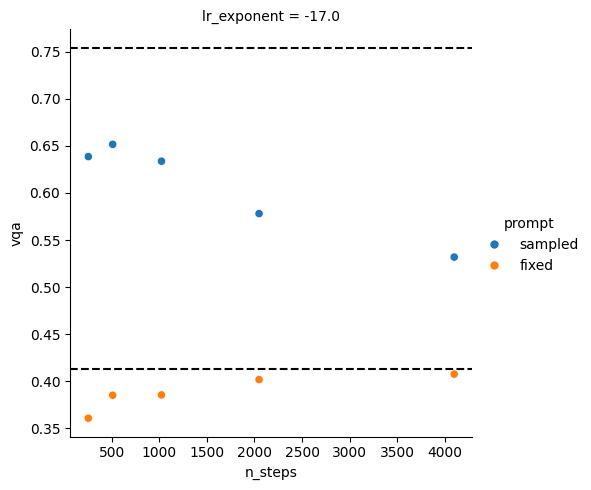

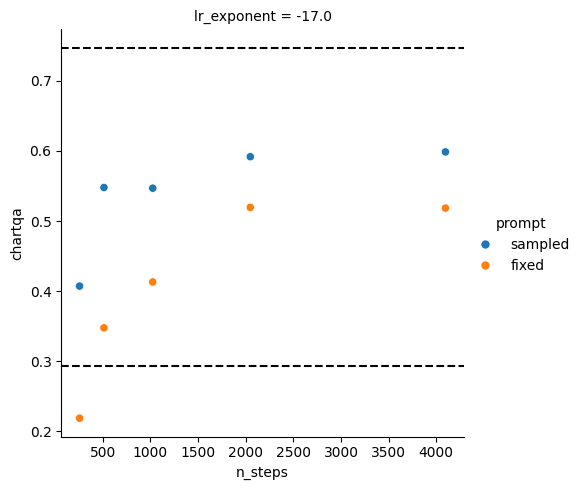

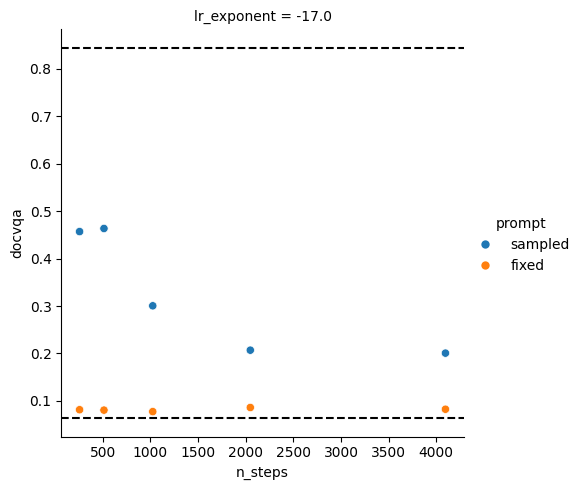

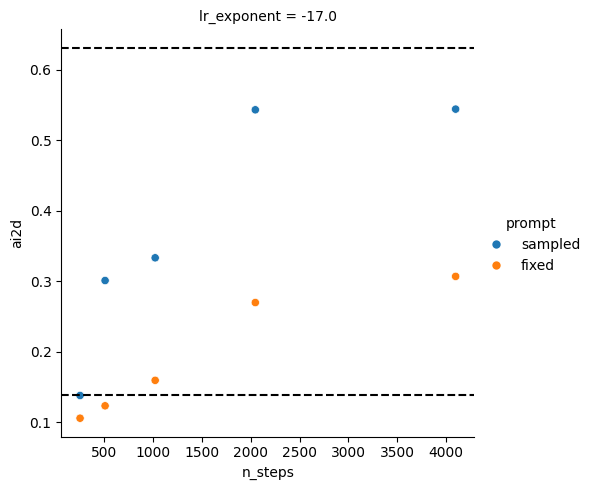

In [19]:
tasks = ["vqa", "chartqa", "docvqa", "ai2d"]
for task in tasks:
    g = sns.relplot(data=df, x="n_steps", y=task, col="lr_exponent", hue="prompt")
    for ax in g.axes.flat:
        ax.axhline(step_0[task][0], linestyle="--", color="black")
        ax.axhline(baseline[task][0], linestyle="--", color="black")

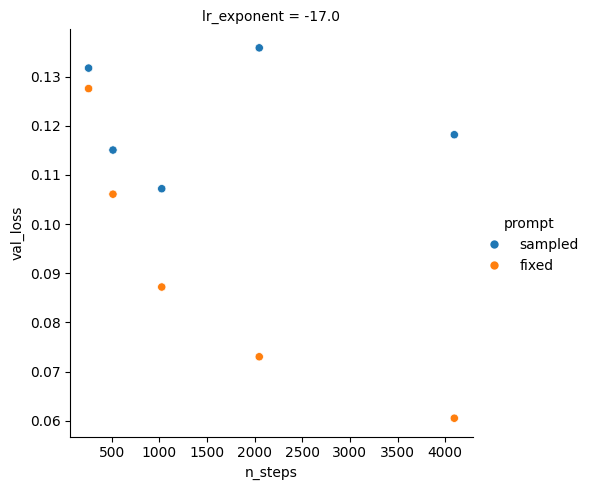

In [21]:
g = sns.relplot(data=df, x="n_steps", y="val_loss", col="lr_exponent", hue="prompt")

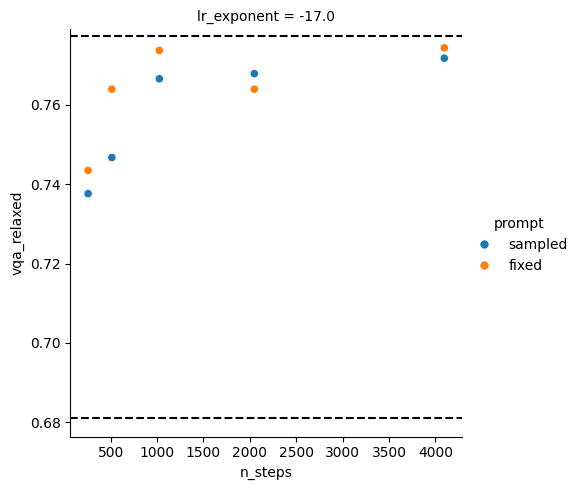

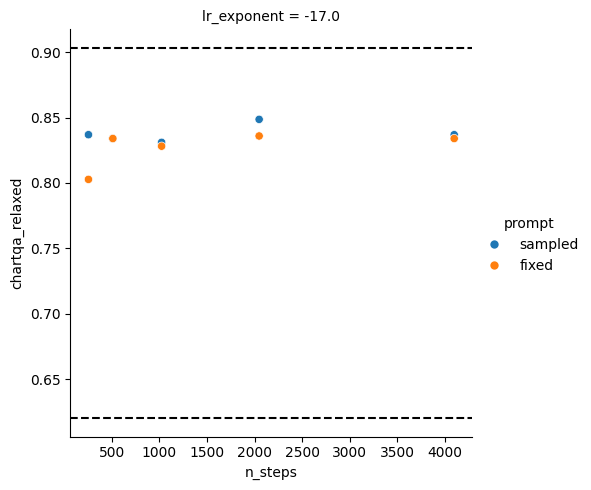

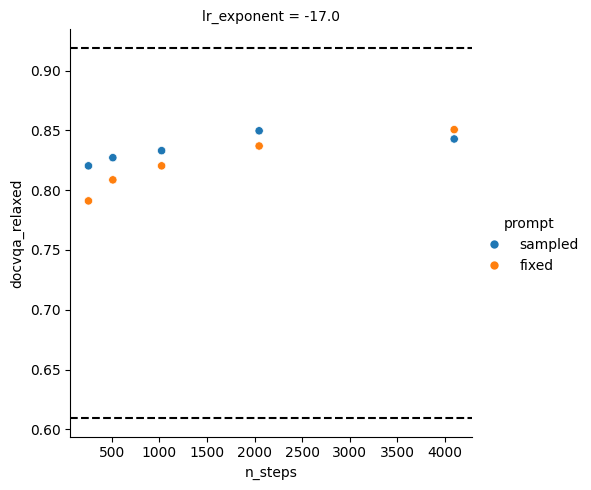

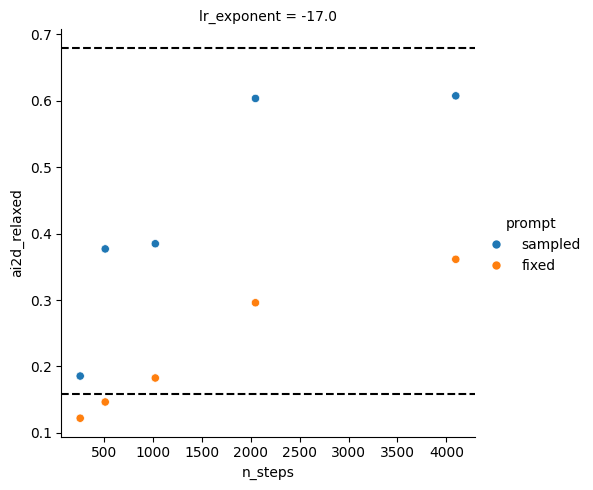

In [22]:
tasks = ["vqa", "chartqa", "docvqa", "ai2d"]
for task in tasks:
    g = sns.relplot(data=df, x="n_steps", y=f"{task}_relaxed", col="lr_exponent", hue="prompt")
    for ax in g.axes.flat:
        ax.axhline(step_0[task][1], linestyle="--", color="black")
        ax.axhline(baseline[task][1], linestyle="--", color="black")